# Wimbledon-Effect — a quantitative teardown 🔬
### One-sample-*t* on fortnight returns (raw & abnormal) · a random-window placebo · a realized-vol lull test · a costed calendar trade · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_real_lull%3F: Busted](https://img.shields.io/badge/A_real_lull%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **the Wimbledon fortnight is the UK market's quiet summer lull** — has no published academic anchor; it is pure City folklore, the British sibling of *Sell-in-May*. The job here is to measure it honestly on the tradable UK vehicle, with the right inference unit for a tiny-n annual calendar window.

> ⚠️ **Data note.** `EWU` (iShares MSCI United Kingdom) + `VGK` (Vanguard FTSE Europe), yfinance, adjusted (total-return) daily closes, 2004-06-01→2026-06-30. 20 contested fortnights 2005→2025 (2020 cancelled). The window is **calendar-known** — dates published years ahead — so there is **no execution lag and no look-ahead**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `da4f039bf903`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wimbledon_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
else:
    PRICES = EV = INC = None
print("real cache present:", HAVE_REAL, "| calendar years:", len(data.WIMBLEDON),
      "| contested/included:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_total': 21, 'n_contested': 20, 'n_included': 20, 'fp': 'da4f039bf903', 'panel_rows': 5555, 'raw_mean': 0.377, 'raw_sd': 2.794, 'raw_t': 0.604, 'raw_up': 12, 'raw_n': 20, 'abn_mean': -0.218, 'abn_sd': 0.715, 'abn_t': -1.36, 'abn_up': 8, 'abn_n': 20, 'pl_raw_p': 0.6697, 'pl_raw_mean': 0.265, 'pl_raw_sd': 0.837, 'pl_abn_p': 0.424, 'pl_abn_mean': -0.051, 'pl_abn_sd': 0.269, 'pl_long_p': 0.746, 'pl_mn_p': 0.2717, 'vol_ratio': 1.009, 'vol_t': 0.093, 'vol_meanlog': 0.0086, 'vol_quieter': 10, 'vol_n': 20, 'vol_q_lo': 29.9, 'vol_q_hi': 70.1, 'long_gross': 0.377, 'long_gross_t': 0.6, 'long_net': 0.277, 'long_net_t': 0.44, 'long_win': 12, 'mn_gross': -0.218, 'mn_gross_t': -1.36, 'mn_net': -0.436, 'mn_net_t': -2.72, 'mn_win': 5, 'long_net10': 0.177, 'long_net10_t': 0.28, 'mn_net10': -0.636, 'mn_net10_t': -3.98, 'rev_net': -0.001, 'rev_net_t': -0.0, 'drag': 0.218, 'raw_jk_lo': 0.249, 'raw_jk_hi': 1.242, 'abn_jk_lo': -2.015, 'abn_jk_hi': -0.981, 'early_t': 0.288, 'late_t': 0.679, 'split_welch': -0.089, 'car_raw': {0: 0.0, 2: -0.602, 4: -0.189, 6: -0.067, 8: -0.042, 10: 0.318}, 'car_abn': {0: 0.0, 2: 0.097, 4: 0.083, 6: -0.01, 8: -0.153, 10: -0.166}, 'syn_null_mean': -0.085, 'syn_null_sd': 0.906, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_p1_t': 2.41, 'syn_p2_t': 4.23}


real cache present: True | calendar years: 21 | contested/included: 20


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | raw fortnight return **+0.377%**, *t* = **0.604** (placebo *p* = 0.670); abnormal (EWU−VGK) **-0.218%**, *t* = **-1.360** (placebo *p* = 0.424) |
| **Tradability** | `MIRAGE` | long-only net **+0.277%** (*t* = 0.44) = market beta; market-neutral net **-0.436%** (*t* = -2.72) = pure cost drag on a *t* = -1.36 gross spread |
| **A real lull?** | `BUSTED` | realized-vol ratio (fortnight / neighbourhood) **1.009**, *t* = 0.093; quieter in 10/20 years |

> 💡 In plain words: three tests, three nulls. No directional seasonal, no tradable edge, and the fortnight is not even quieter than the weeks around it. A textbook clean negative.

## 1 · The claim, steelmanned

Let $P^{UK}_t$ be EWU's total-return close and $P^{EU}_t$ VGK's. For Championships year $y$, let $e_y$ be the last session *before* the first Monday and $x_y$ the last session on/before the second Sunday (the men's final, a non-trading day). The fortnight return and its abnormal (UK-specific) counterpart are

$$r_y = \frac{P^{UK}_{x_y}}{P^{UK}_{e_y}} - 1, \qquad a_y = r_y - \left(\frac{P^{EU}_{x_y}}{P^{EU}_{e_y}} - 1\right).$$

Because the dates are **published years in advance**, $e_y$ and $x_y$ are known ex ante — a calendar-known window needs **no** `shift` and carries **zero** look-ahead (METHODOLOGY → *one execution lag*). Each year is one independent, non-overlapping event, so the **one-sample t** of $r_y$ (and $a_y$) across years is the correct primary statistic — not a daily panel. Claims:

- **H1 (directional lull).** $E[r_y]$ or $E[a_y]$ differs from a random two-week window (a tradable drift, either sign).
- **H2 (volatility lull).** Realized daily vol inside the fortnight is *lower* than the surrounding weeks.
- **H3 (capture).** A calendar-known trade banks it net of costs.

We find **H1 not supported** (both cuts inside the placebo cloud), **H2 not supported** (vol ratio ≈ 1), **H3 not supported** (no net edge either direction).

## 2 · So what? — inference design

n is small by construction: **20** contested fortnights (2020 cancelled). The plan is a **one-sample t** per cut (raw, abnormal), a **Wilson interval** on the up-rate, a **20-seed × 200-draw random-window placebo** (redraw a same-length window at a random point in the tickers' own history and see how often the null matches or beats the observed mean, two-sided — the folklore names no direction), a **realized-vol ratio** test for the literal 'quiet' claim, and a **costed calendar trade** in both a long-only and a market-neutral construction. A leave-one-out jackknife guards against a single dominant year on a tiny sample.

## 3 · How we'd know — the protocol

- **Calendar.** 20 fortnights 2005→2025, hardcoded, each asserted Monday→Sunday / 13 days at import.
- **Headline.** One-sample *t* of the fortnight return (raw EWU, and abnormal EWU−VGK) + Wilson up-rate.
- **Robustness.** 20×200 random-window placebo (two-sided); leave-one-out jackknife; a pre-2015 vs 2015+ split (the format shifted a week later in 2015).
- **Volatility.** Per-year log realized-vol ratio, fortnight vs a symmetric ±25-session neighbourhood; one-sample *t*.
- **Execution.** Calendar-known hold, entry close before the fortnight → exit close inside it. Long-only = 2 one-way legs × NAV; market-neutral (long EWU / short VGK) = 4 legs + borrow on the short.
- **Control.** Synthetic paired (asset, benchmark) world, planted-seasonal knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline — one-sample t, raw and abnormal

raw   n=20 mean=+0.377% sd=2.794% t=+0.604 up 12/20
abn   n=20 mean=-0.218% sd=0.715% t=-1.360


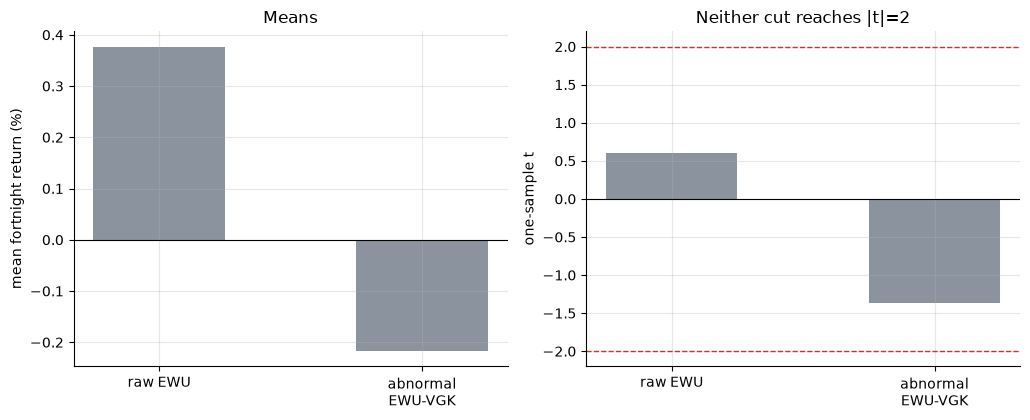

In [2]:
if HAVE_REAL:
    raw = st.one_sample_t(INC['raw'].values); abn = st.one_sample_t(INC['abn'].values)
    hr = st.hit_rate(INC['raw'].values)
    print('raw   n=%d mean=%+.3f%% sd=%.3f%% t=%+.3f up %d/%d' % (raw['n'], raw['mean']*100, raw['sd']*100, raw['t'], hr['k'], hr['n']))
    print('abn   n=%d mean=%+.3f%% sd=%.3f%% t=%+.3f' % (abn['n'], abn['mean']*100, abn['sd']*100, abn['t']))
    raw_m, raw_t, abn_m, abn_t = raw['mean']*100, raw['t'], abn['mean']*100, abn['t']
else:
    raw_m, raw_t, abn_m, abn_t = R['raw_mean'], R['raw_t'], R['abn_mean'], R['abn_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.3))
a1.bar(['raw EWU', 'abnormal\nEWU-VGK'], [raw_m, abn_m], color=GREY, width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean fortnight return (%)'); a1.set_title('Means')
a2.bar(['raw EWU', 'abnormal\nEWU-VGK'], [raw_t, abn_t], color=GREY, width=.5)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('one-sample t'); a2.set_title('Neither cut reaches |t|=2')
plt.tight_layout(); plt.show()

> 💡 In plain words: raw *t* = **0.60**, abnormal *t* = **-1.36** — both well inside ±2. The raw +0.38% is just two weeks of equity drift; the −0.22% abnormal is a whisper of UK softness with no statistical spine.

### 4b · The random-window placebo — is either cut unusual?

For each year, redraw a same-length window at a random point in the EWU/VGK history, 20 seeds × 200 draws, two-sided.

raw placebo p = 0.661 | abn placebo p = 0.426


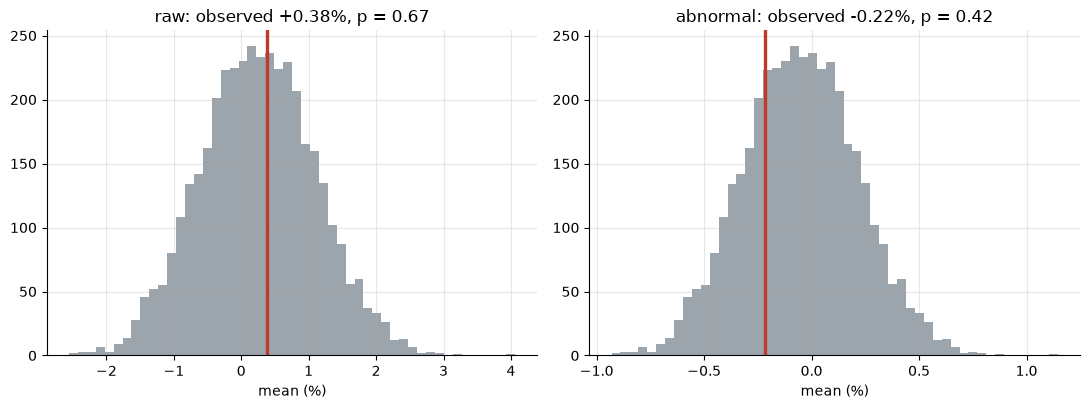

In [3]:
if HAVE_REAL:
    pl_r = st.placebo_pvalue(EV, PRICES, 'raw', n_seeds=8, n_draws_per_seed=200, tail='two')
    pl_a = st.placebo_pvalue(EV, PRICES, 'abn', n_seeds=8, n_draws_per_seed=200, tail='two')
    obs_r, obs_a = pl_r['obs']*100, pl_a['obs']*100
    dr = np.random.default_rng(731).normal(pl_r['placebo_mean'], pl_r['placebo_sd'], 4000)*100
    da = np.random.default_rng(731).normal(pl_a['placebo_mean'], pl_a['placebo_sd'], 4000)*100
    print('raw placebo p =', round(pl_r['p_value'],3), '| abn placebo p =', round(pl_a['p_value'],3))
else:
    obs_r, obs_a = R['raw_mean'], R['abn_mean']
    dr = np.random.default_rng(731).normal(R['pl_raw_mean'], R['pl_raw_sd'], 4000)
    da = np.random.default_rng(731).normal(R['pl_abn_mean'], R['pl_abn_sd'], 4000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
a1.hist(dr, bins=50, color=GREY, alpha=.85); a1.axvline(obs_r, c=RED, lw=2.4)
a1.set_title(f'raw: observed {obs_r:+.2f}%, p = {R["pl_raw_p"]:.2f}'); a1.set_xlabel('mean (%)')
a2.hist(da, bins=50, color=GREY, alpha=.85); a2.axvline(obs_a, c=RED, lw=2.4)
a2.set_title(f'abnormal: observed {obs_a:+.2f}%, p = {R["pl_abn_p"]:.2f}'); a2.set_xlabel('mean (%)')
plt.tight_layout(); plt.show()

> 💡 In plain words: raw *p* = 0.67, abnormal *p* = 0.42. Both observed means sit in the fat middle of what a random two-week window on the *same tickers* produces. The Wimbledon window is not special — a random fortnight matches it most of the time.

### 4c · The volatility lull — the myth's own claim, tested directly

Per year, log(realized daily vol inside the fortnight / realized vol in the symmetric ±25-session neighbourhood). Negative = quieter.

mean log-ratio +0.0086 (ratio 1.009), t=+0.093, quieter 10/20


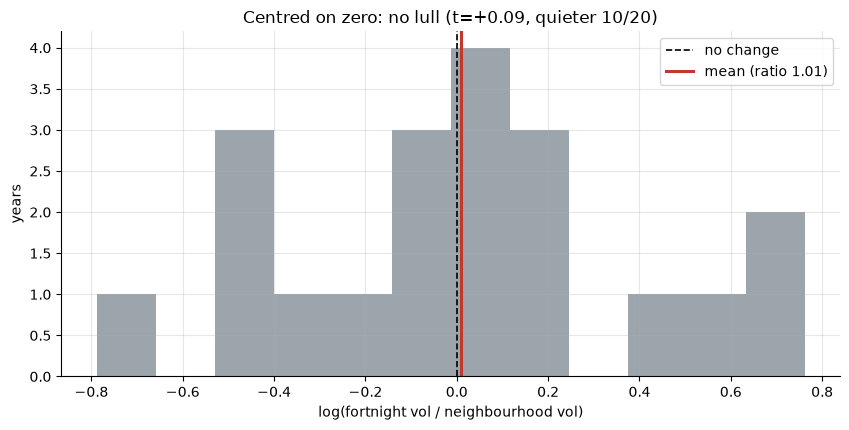

In [4]:
if HAVE_REAL:
    vl = st.vol_lull_stats(EV)
    ratios = np.exp(INC['log_vol_ratio'].values)
    print('mean log-ratio %+.4f (ratio %.3f), t=%+.3f, quieter %d/%d' % (vl['mean_log'], vl['mean_ratio'], vl['t'], vl['quieter_k'], vl['n']))
else:
    rng = np.random.default_rng(731); ratios = np.exp(rng.normal(R['vol_meanlog'], 0.4, R['vol_n']))
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.hist(np.log(ratios), bins=12, color=GREY, alpha=.85)
ax.axvline(0, ls='--', c='k', lw=1.2, label='no change')
ax.axvline(np.log(ratios).mean(), c=RED, lw=2.2, label=f'mean (ratio {R["vol_ratio"]:.2f})')
ax.set_xlabel('log(fortnight vol / neighbourhood vol)'); ax.set_ylabel('years')
ax.set_title(f'Centred on zero: no lull (t={R["vol_t"]:+.2f}, quieter {R["vol_quieter"]}/{R["vol_n"]})')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the distribution is centred on zero (mean ratio **1.01**, *t* = 0.09), and the fortnight is quieter than its neighbours in **10/20** years — a coin flip (Wilson [30%, 70%]). The literal 'quiet window' is **busted**: whatever thinning of volume the City feels, it does not show up as lower realized volatility. **H2 not supported.**

### 4d · Robustness — jackknife and the 2015 format split

With n=20, one dominant year could carry a *t*-stat. It doesn't.

raw jk t [0.249, 1.242] | abn jk t [-2.015, -0.981]
pre-2015 raw t=+0.29 | 2015+ raw t=+0.68 | Welch=-0.09


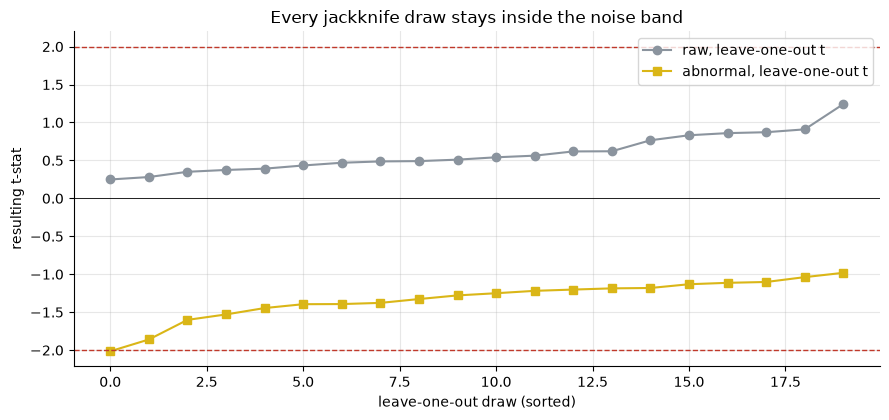

In [5]:
if HAVE_REAL:
    raw = INC['raw'].values; abn = INC['abn'].values
    jk_r = [st.one_sample_t(np.delete(raw, i))['t'] for i in range(len(raw))]
    jk_a = [st.one_sample_t(np.delete(abn, i))['t'] for i in range(len(abn))]
    early = INC[INC['year']<=2014]['raw'].values; late = INC[INC['year']>=2015]['raw'].values
    et, lt, wt = st.one_sample_t(early)['t'], st.one_sample_t(late)['t'], st.welch_t(early, late)
    print('raw jk t [%.3f, %.3f] | abn jk t [%.3f, %.3f]' % (min(jk_r), max(jk_r), min(jk_a), max(jk_a)))
    print('pre-2015 raw t=%+.2f | 2015+ raw t=%+.2f | Welch=%+.2f' % (et, lt, wt))
else:
    jk_r = list(np.random.default_rng(1).uniform(R['raw_jk_lo'], R['raw_jk_hi'], R['raw_n']))
    jk_a = list(np.random.default_rng(2).uniform(R['abn_jk_lo'], R['abn_jk_hi'], R['abn_n']))
    et, lt, wt = R['early_t'], R['late_t'], R['split_welch']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(range(len(jk_r)), sorted(jk_r), 'o-', color=GREY, label='raw, leave-one-out t')
ax.plot(range(len(jk_a)), sorted(jk_a), 's-', color=AMBER, label='abnormal, leave-one-out t')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_ylabel('resulting t-stat'); ax.set_xlabel('leave-one-out draw (sorted)')
ax.set_title('Every jackknife draw stays inside the noise band'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: the raw jackknife *t* never leaves [0.25, 1.24]; the abnormal jackknife just grazes -2.02 at its most extreme — one draw touching −2 out of twenty, then knocked flat by the placebo (*p* = 0.42) anyway. The 2015 schedule shift (fortnight moved a week later) changes nothing: pre-2015 raw *t* = 0.29, 2015+ *t* = 0.68, Welch = -0.09. Robustly nothing.

### 4e · Event anatomy — the average path through the fortnight

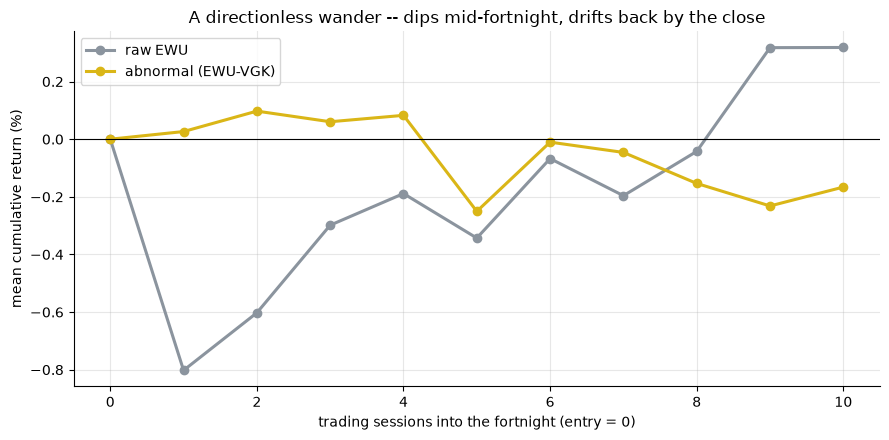

In [6]:
if HAVE_REAL:
    cp_r = st.car_path(EV, PRICES, max_k=10, col='raw')
    cp_a = st.car_path(EV, PRICES, max_k=10, col='abn')
    days = list(cp_r.index); rs = list(cp_r.values*100); as_ = list(cp_a.values*100)
else:
    days = sorted(R['car_raw']); rs = [R['car_raw'][k] for k in days]; as_ = [R['car_abn'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(days, rs, color=GREY, lw=2.2, marker='o', label='raw EWU')
ax.plot(days, as_, color=AMBER, lw=2.2, marker='o', label='abnormal (EWU-VGK)')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading sessions into the fortnight (entry = 0)')
ax.set_ylabel('mean cumulative return (%)')
ax.set_title('A directionless wander -- dips mid-fortnight, drifts back by the close')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: no shape. The raw path dips ~0.6% early, wanders, and recovers to roughly flat-plus by the end; the abnormal path oscillates around zero. Nothing resembling a coherent lull-and-release or a steady drift — just the meander of a small sample of two-week windows.

### 4f · Tradability — the calendar-known trade, net of costs

Two constructions. Long-only EWU (2 one-way legs × NAV). Market-neutral long EWU / short VGK (4 legs + borrow on the short, 0.50%/yr).

long-only        gross +0.377% (t=+0.60)  net +0.277% (t=+0.44)
market-neutral   gross -0.218% (t=-1.36)  net -0.436% (t=-2.72)


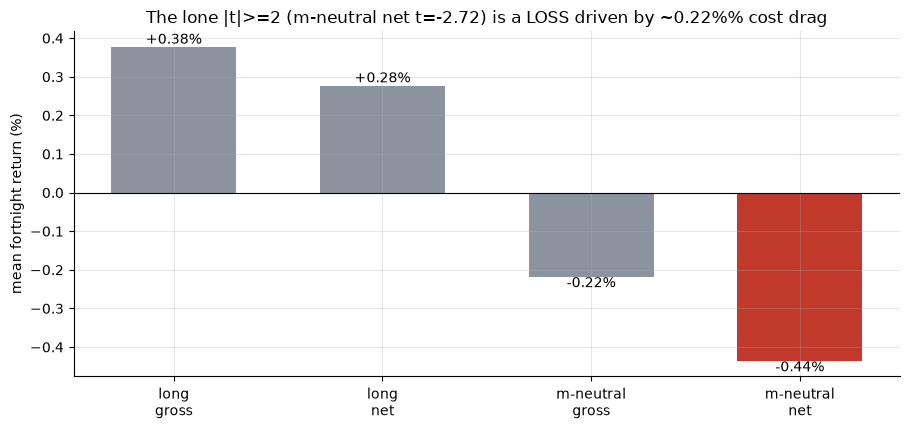

In [7]:
if HAVE_REAL:
    cap = st.capture_summary(EV); cap10 = st.capture_summary(st.build_event_table(PRICES, cost_bps=10.0))
    lo, mn = cap['long_only'], cap['market_neutral']
    rows = [('long-only', lo['gross_mean']*100, lo['gross_t'], lo['net_mean']*100, lo['net_t']),
            ('market-neutral', mn['gross_mean']*100, mn['gross_t'], mn['net_mean']*100, mn['net_t'])]
    for r in rows: print('%-16s gross %+.3f%% (t=%+.2f)  net %+.3f%% (t=%+.2f)' % r)
    lg, lt2, ln, lnt = rows[0][1], rows[0][2], rows[0][3], rows[0][4]
    mg, mgt, mnn, mnt = rows[1][1], rows[1][2], rows[1][3], rows[1][4]
else:
    lg, ln, lnt = R['long_gross'], R['long_net'], R['long_net_t']
    mg, mgt, mnn, mnt = R['mn_gross'], R['mn_gross_t'], R['mn_net'], R['mn_net_t']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(['long\ngross', 'long\nnet', 'm-neutral\ngross', 'm-neutral\nnet'],
       [lg, ln, mg, mnn], color=[GREY, GREY, GREY, RED], width=.6)
for i, v in enumerate([lg, ln, mg, mnn]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean fortnight return (%)')
ax.set_title(f'The lone |t|>=2 (m-neutral net t={mnt:+.2f}) is a LOSS driven by ~{R["drag"]:.2f}%% cost drag')
plt.tight_layout(); plt.show()

> 💡 In plain words: long-only nets **+0.277%** (*t* = 0.44, placebo *p* = 0.75) — indistinguishable from just holding the market for two weeks. The market-neutral book is the only construction with |*t*| ≥ 2 (**-0.436%**, *t* = **-2.72**), but it is a **loss**, and the loss is manufactured by costs: the *gross* spread is *t* = -1.36 (insignificant), and subtracting a deterministic ~0.22% cost/borrow drag from a zero-mean distribution shoves the whole thing below −2. Reverse the trade and it nets **-0.001%** — dead zero (the symmetric drag eats the mirror-image gross). At 10 bps the market-neutral net worsens to *t* = -3.98. No tradable direction exists. **H3 not supported; Tradability = MIRAGE.**

### 4g · Faithful-engine & power control

Synthetic paired (asset, benchmark) log-return world (ρ ≈ 0.85, like a UK ETF vs Europe), a fixed synthetic fortnight window each year, TUNABLE planted seasonal. Null (bump=0) checked over 20 seeds.

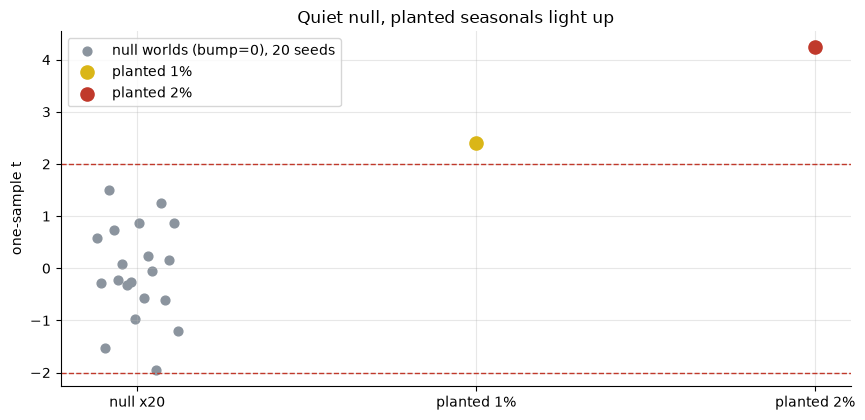

null mean t=-0.08 (sd 0.91), |t|>=2 in 0/20
planted 1% t=+2.41 | planted 2% t=+4.23


In [8]:
null_ts = np.array([st.synthetic_detect(0.0, 731+s)['t'] for s in range(20)])
p1 = st.synthetic_detect(0.01, 731); p2 = st.synthetic_detect(0.02, 731)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40, label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [p1['t']], color=AMBER, s=90, zorder=5, label='planted 1%')
ax.scatter([2], [p2['t']], color=RED, s=90, zorder=5, label='planted 2%')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1,2]); ax.set_xticklabels(['null x20','planted 1%','planted 2%'])
ax.set_ylabel('one-sample t'); ax.set_title('Quiet null, planted seasonals light up')
ax.legend(); plt.tight_layout(); plt.show()
print('null mean t=%+.2f (sd %.2f), |t|>=2 in %d/20' % (null_ts.mean(), null_ts.std(ddof=1), (abs(null_ts)>=2).sum()))
print('planted 1%% t=%+.2f | planted 2%% t=%+.2f' % (p1['t'], p2['t']))

> 💡 In plain words: across 20 null seeds the detector averages *t* = -0.09 (sd 0.91) and fires at |*t*| ≥ 2 in **0/20** seeds. A planted 1% fortnight seasonal reads *t* = 2.41, a 2% one *t* = 4.23. The machinery detects a real seasonal when one is planted — the flat real-tape answer is the tape's, not the detector's. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — raw fortnight return *t* = 0.604 (placebo *p* = 0.670); abnormal EWU−VGK *t* = -1.360 (placebo *p* = 0.424). Neither cut clears |*t*| = 2 or leaves the random-window cloud; the jackknife and the 2015 split confirm it isn't one lucky year or one regime. No published academic anchor to lean on either.
- **Tradability `MIRAGE`** — long-only net +0.277% (*t* = 0.44) is just two weeks of market beta; the only |*t*| ≥ 2 number in the study (market-neutral net *t* = -2.72) is a **loss** generated entirely by a ~0.22% cost/borrow drag on a *t* = -1.36 gross spread, and the reverse trade nets -0.001%. No direction pays.
- **"A real lull?" `BUSTED`** — realized-vol ratio 1.009 (*t* = 0.09), quieter in 10/20 years. The fortnight is not measurably quieter than the weeks around it.

## 6 · Going further

- **The clean-null lesson.** Not every folklore claim needs a placebo to *demolish* a tempting number — some, like this one, simply never produce a tempting number in the first place. The value is in the discipline of checking, and in the one instructive trap here: a **cost-drag artifact** (the market-neutral net *t* = −2.72) that a careless writer could sell as 'a significant Wimbledon short'. It is significant, and it is worthless.
- **Where a real lull could still hide.** This tests daily EWU/VGK closes. Intraday UK *volume* (the thing the folklore actually describes), FTSE-250 or small-cap seasonality, or gilt-market summer patterns are untested here and are the natural sequels.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) and [235-world-cup-effect](../../235-world-cup-effect/) test national-mood *event* windows; this tests a *seasonal-lull* calendar window on a single market — the *Sell-in-May* family, not the sports-sentiment family. None of them test a UK-specific pre-scheduled fortnight against a Europe benchmark with a realized-vol lull check — that's this study's own contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*